# 05. Tối ưu XGBoost, ảnh hưởng siêu tham số và kiểm toán Pareto

**Mục tiêu:** trả lời RQ1–RQ3 bằng lịch sử trial, so sánh TPE với NSGA-II và tái hiện quy tắc chọn ba nghiệm trên Development.

TPE tối đa hóa $f_1=\mathrm{AUC}_{CV}$; NSGA-II tối đa hóa cả $f_1$ và $f_2=S$, tương quan Spearman trung bình giữa global SHAP importance của 5 mô hình fold trên cùng Reference 1.000 mẫu. Jaccard top-5 là chỉ số bổ sung, **không nằm trong hai mục tiêu tối ưu**.

Không chạy HPO hoặc huấn luyện mô hình tín dụng. Phần importance chỉ fit mô hình hồi quy phụ trên **bảng trial** để giải thích mối liên hệ thăm dò; không đọc dữ liệu khách hàng hoặc Final Test.


## 1. Nạp lịch sử và xác nhận cùng giao thức


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display

project_root = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / 'configs' / 'data.yaml').is_file()), None)
if project_root is None:
    raise FileNotFoundError('Không tìm thấy thư mục dự án chứa configs/data.yaml.')
sys.path.insert(0, str(project_root / 'src'))
from creditrisk import visualization as viz
viz.set_scientific_theme()

tables = project_root / 'artifacts' / 'tables'
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda x: f'{x:.6f}')

def read_table(name, required=()):
    path = tables / name
    if not path.is_file():
        raise FileNotFoundError(f'Thiếu artifact: {path}. Cần cung cấp kết quả đã lưu; notebook không chạy lại thực nghiệm.')
    frame = pd.read_csv(path)
    missing = set(required) - set(frame.columns)
    if missing:
        raise ValueError(f'{name} thiếu cột {sorted(missing)}')
    return frame

def show_figure(figure):
    display(figure)
    plt.close(figure)

with (project_root / 'configs' / 'data.yaml').open() as stream:
    data_config = yaml.safe_load(stream)
print('Chế độ phân tích artifact: không nạp dữ liệu tín dụng, không huấn luyện lại, không chấm lại Final Test.')


Chế độ phân tích artifact: không nạp dữ liệu tín dụng, không huấn luyện lại, không chấm lại Final Test.


In [2]:
single = read_table('xgb_single_hpo_trials.csv', ['trial', 'state', 'roc_auc_cv', 'shap_stability'])
multi = read_table('xgb_multi_hpo_trials.csv', ['trial', 'state', 'roc_auc_cv', 'shap_stability'])
single_best = read_table('xgb_single_hpo_best.csv')
default = read_table('xgb_default_objectives.csv')
pareto = read_table('xgb_multi_hpo_pareto.csv')
selected = read_table('xgb_pareto_selected.csv')
audit = read_table('xgb_pareto_audit.csv')
comparison = read_table('xgb_pareto_comparison.csv')
manifests = pd.concat([read_table('xgb_single_hpo_manifest.csv'),
                       read_table('xgb_multi_hpo_manifest.csv')], ignore_index=True)
assert manifests['protocol_fingerprint'].nunique() == 1
assert single['trial'].is_unique and multi['trial'].is_unique
single = single.loc[single['state'].eq('COMPLETE')].copy()
multi = multi.loc[multi['state'].eq('COMPLETE')].copy()
display(manifests[['study_name', 'sampler_name', 'complete_trials', 'failed_trials',
                   'model_fits_complete', 'shap_evaluations_complete', 'trial_duration_seconds_total']])
print(f'Hoàn thành: TPE {len(single)} trial; NSGA-II {len(multi)} trial; front {len(pareto)} nghiệm.')


,study_name,sampler_name,complete_trials,failed_trials,model_fits_complete,shap_evaluations_complete,trial_duration_seconds_total
0,xgb_auc_tpe,TPESampler,64,0,320,320,541.068877
1,xgb_auc_shap_nsgaii,NSGAIISampler,64,0,320,320,325.786956


Hoàn thành: TPE 64 trial; NSGA-II 64 trial; front 6 nghiệm.


## 2. RQ1: khảo sát 9 siêu tham số

Hai lớp bằng chứng bổ sung nhau:

1. **Tương quan Spearman theo từng sampler:** chỉ thể hiện liên hệ đơn biến, không kiểm soát tương tác hoặc đồng biến giữa tham số.
2. **Permutation importance ngoài fold của hồi quy phụ:** học ánh xạ siêu tham số → mục tiêu từ log trial, sau đó xáo trộn từng tham số trong fold giữ lại. Importance là độ giảm $R^2$; có thể âm và không phải phần trăm đóng góp.

Phân tích mỗi nhánh riêng để tránh trộn hai cơ chế lấy mẫu. Với tham số log-uniform dùng `log10`. `GroupKFold` giữ các cấu hình trùng nhau trong cùng fold, tránh việc cấu hình trùng xuất hiện ở cả train và validation của mô hình phụ. Cần đọc $R^2$ ngoài fold trước khi diễn giải importance; $R^2$ thấp hoặc âm báo hiệu mô hình phụ chưa mô tả tốt mục tiêu.

**Giới hạn:** mỗi nhánh chỉ có 64 trial được lấy mẫu thích ứng và cùng một dữ liệu Core/Reference. Importance phụ thuộc phạm vi tìm kiếm, tương tác và mật độ trial; không suy ra quan hệ nhân quả hoặc tầm quan trọng phổ quát. Độ lệch chuẩn importance qua 4 fold không phải khoảng tin cậy quần thể.


In [3]:
parameters = ['max_depth', 'learning_rate', 'n_estimators', 'subsample', 'colsample_bytree',
              'min_child_weight', 'gamma', 'reg_alpha', 'reg_lambda']
parameter_columns = [f'param_{name}' for name in parameters]
with (project_root / 'configs' / 'xgb_search_space.yaml').open() as stream:
    search_config = yaml.safe_load(stream)['search_space']
display(pd.DataFrame([{'parameter': name, 'low': search_config[name]['low'],
                       'high': search_config[name]['high'], 'log_scale': search_config[name].get('log', False)}
                      for name in parameters]))
associations = []
for sampler, frame in [('TPE', single), ('NSGA-II', multi)]:
    for name in parameters:
        associations.append({'sampler': sampler, 'parameter': name,
                             'Spearman_with_AUC': frame[f'param_{name}'].corr(frame['roc_auc_cv'], method='spearman'),
                             'Spearman_with_stability': frame[f'param_{name}'].corr(frame['shap_stability'], method='spearman')})
display(pd.DataFrame(associations).round(4))


,parameter,low,high,log_scale
0,max_depth,2.000000,10.000000,False
1,learning_rate,0.010000,0.300000,True
2,n_estimators,100.000000,1000.000000,False
3,subsample,0.500000,1.000000,False
4,colsample_bytree,0.500000,1.000000,False
5,min_child_weight,1.000000,15.000000,False
6,gamma,0.000000,10.000000,False
7,reg_alpha,0.000100,10.000000,True
8,reg_lambda,0.001000,100.000000,True


,sampler,parameter,Spearman_with_AUC,Spearman_with_stability
0,TPE,max_depth,0.204400,-0.000300
1,TPE,learning_rate,-0.469600,-0.446100
2,TPE,n_estimators,0.236000,-0.001300
3,TPE,subsample,-0.486000,-0.038000
4,TPE,colsample_bytree,-0.179800,-0.478000
5,TPE,min_child_weight,-0.365300,-0.131500
6,TPE,gamma,-0.011600,0.422500
7,TPE,reg_alpha,-0.254600,0.038200
8,TPE,reg_lambda,0.348600,0.426000
9,NSGA-II,max_depth,0.172400,0.105600


mean       min      max
sampler objective                                  
NSGA-II roc_auc_cv     -0.297890 -1.308150 0.123538
        shap_stability  0.384385  0.227792 0.504551
TPE     roc_auc_cv     -0.196920 -1.489928 0.499861
        shap_stability -0.430892 -2.414236 0.529053

**Giới hạn importance ở lần thực thi này:** trung bình R² ngoài fold ≤ 0 cho **NSGA-II/roc_auc_cv, TPE/roc_auc_cv, TPE/shap_stability**. Không dùng importance của các mô hình phụ đó để kết luận tham số nào đóng góp nhiều nhất; chỉ xem như chẩn đoán. Các liên hệ Spearman vẫn là mô tả, không phải nhân quả.

mean      std
sampler objective      parameter                          
NSGA-II roc_auc_cv     colsample_bytree  0.073500 0.055600
                       gamma             0.073100 0.086100
                       learning_rate     0.049200 0.025300
                       max_depth         0.028100 0.060100
                       min_child_weight -0.019300 0.028100
                       n_estimators      0.091700 0.078100
                       reg_alpha         0.091100 0.110000
                       reg_lambda        0.013400 0.050200
                       subsample        -0.017600 0.050700
        shap_stability colsample_bytree  0.000100 0.016900
                       gamma             0.090500 0.037000
                       learning_rate     0.427100 0.053700
                       max_depth         0.001100 0.009900
                       min_child_weight -0.008100 0.035200
                       n_estimators      0.025800 0.007200
                       reg_alpha        -0.014200 0.017000
                       reg_lambda        0.176300 0.112900
                       subsample         0.018300 0.021200
TPE     roc_auc_cv     colsample_bytree  0.001100 0.007200
                       gamma             0.034900 0.058900
                       learning_rate     0.046600 0.154300
                       max_depth        -0.044000 0.115800
                       min_child_weight  0.023700 0.056000
                       n_estimators     -0.001200 0.005900
                       reg_alpha        -0.009600 0.020300
                       reg_lambda       -0.025500 0.183400
                       subsample         0.004700 0.019900
        shap_stability colsample_bytree  0.153000 0.083700
                       gamma             0.095600 0.073300
                       learning_rate     0.262500 0.198900
                       max_depth        -0.013700 0.034100
                       min_child_weight -0.029800 0.055100
                       n_estimators      0.034600 0.060500
                       reg_alpha        -0.033800 0.044700
                       reg_lambda        0.057200 0.227300
                       subsample         0.053500 0.076800

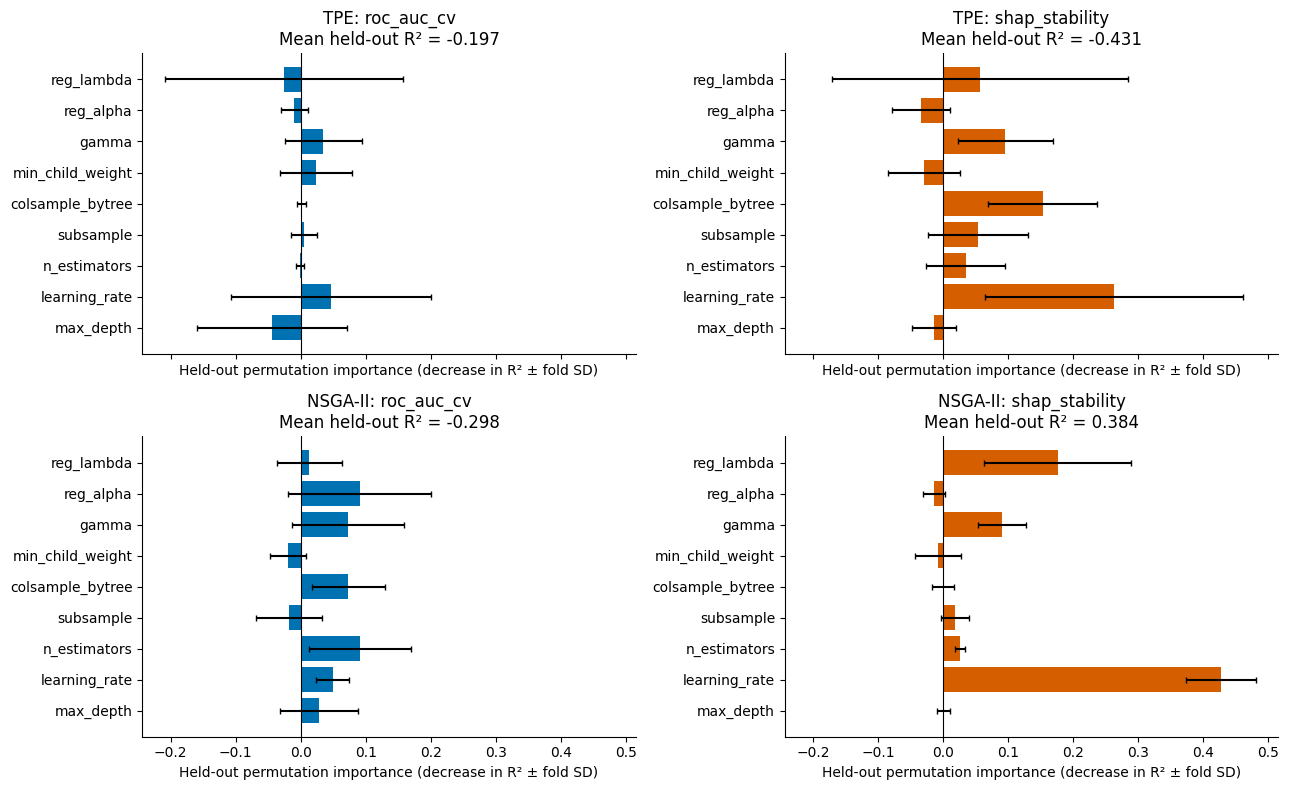

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score
from sklearn.model_selection import GroupKFold

importance_rows, surrogate_scores = [], []
for sampler, frame in [('TPE', single), ('NSGA-II', multi)]:
    X = frame[parameter_columns].copy().reset_index(drop=True)
    for name in parameters:
        if search_config[name].get('log', False):
            X[f'param_{name}'] = np.log10(X[f'param_{name}'])
    groups = pd.util.hash_pandas_object(X, index=False).to_numpy()
    splitter = GroupKFold(n_splits=4)
    for objective in ['roc_auc_cv', 'shap_stability']:
        y = frame[objective].reset_index(drop=True)
        for fold, (train_idx, validation_idx) in enumerate(splitter.split(X, y, groups)):
            surrogate = RandomForestRegressor(n_estimators=160, min_samples_leaf=3,
                                              max_features=0.8, random_state=42 + fold, n_jobs=1)
            surrogate.fit(X.iloc[train_idx], y.iloc[train_idx])
            score = r2_score(y.iloc[validation_idx], surrogate.predict(X.iloc[validation_idx]))
            surrogate_scores.append({'sampler': sampler, 'objective': objective, 'fold': fold, 'heldout_R2': score})
            importance = permutation_importance(surrogate, X.iloc[validation_idx], y.iloc[validation_idx],
                                                scoring='r2', n_repeats=20, random_state=420 + fold, n_jobs=1)
            importance_rows.extend({'sampler': sampler, 'objective': objective, 'parameter': name,
                                    'fold': fold, 'importance': float(value)}
                                   for name, value in zip(parameters, importance.importances_mean))
importance_results = pd.DataFrame(importance_rows)
importance_summary = importance_results.groupby(['sampler', 'objective', 'parameter'])['importance'].agg(['mean', 'std'])
score_summary = pd.DataFrame(surrogate_scores).groupby(['sampler', 'objective'])['heldout_R2'].agg(['mean', 'min', 'max'])
display(score_summary)
weak_surrogates = score_summary.loc[score_summary['mean'] <= 0]
if not weak_surrogates.empty:
    labels = ', '.join(f'{sampler}/{objective}' for sampler, objective in weak_surrogates.index)
    display(Markdown(f'**Giới hạn importance ở lần thực thi này:** trung bình R² ngoài fold ≤ 0 cho **{labels}**. '
                     'Không dùng importance của các mô hình phụ đó để kết luận tham số nào đóng góp nhiều nhất; '
                     'chỉ xem như chẩn đoán. Các liên hệ Spearman vẫn là mô tả, không phải nhân quả.'))
display(importance_summary.round(4))
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for row, sampler in enumerate(['TPE', 'NSGA-II']):
    for col, objective in enumerate(['roc_auc_cv', 'shap_stability']):
        values = importance_summary.loc[(sampler, objective)].reindex(parameters)
        axes[row, col].barh(parameters, values['mean'], xerr=values['std'],
                            color='#0072B2' if col == 0 else '#D55E00', capsize=2)
        axes[row, col].axvline(0, color='black', linewidth=0.8)
        axes[row, col].set_title(f'{sampler}: {objective}\nMean held-out R² = {score_summary.loc[(sampler, objective), "mean"]:.3f}')
        axes[row, col].set_xlabel('Held-out permutation importance (decrease in R² ± fold SD)')
fig.tight_layout()
show_figure(fig)


### Phân bố tham số và parallel coordinates

Phân bố trial cho biết sampler dành ngân sách ở đâu; không thay thế importance. Parallel coordinates chuẩn hóa theo **biên tìm kiếm đã khóa**, với các chiều log theo `log10`, để so sánh TPE và ba đại diện Pareto. Đường gần nhau không đồng nghĩa giải thích SHAP giống nhau.


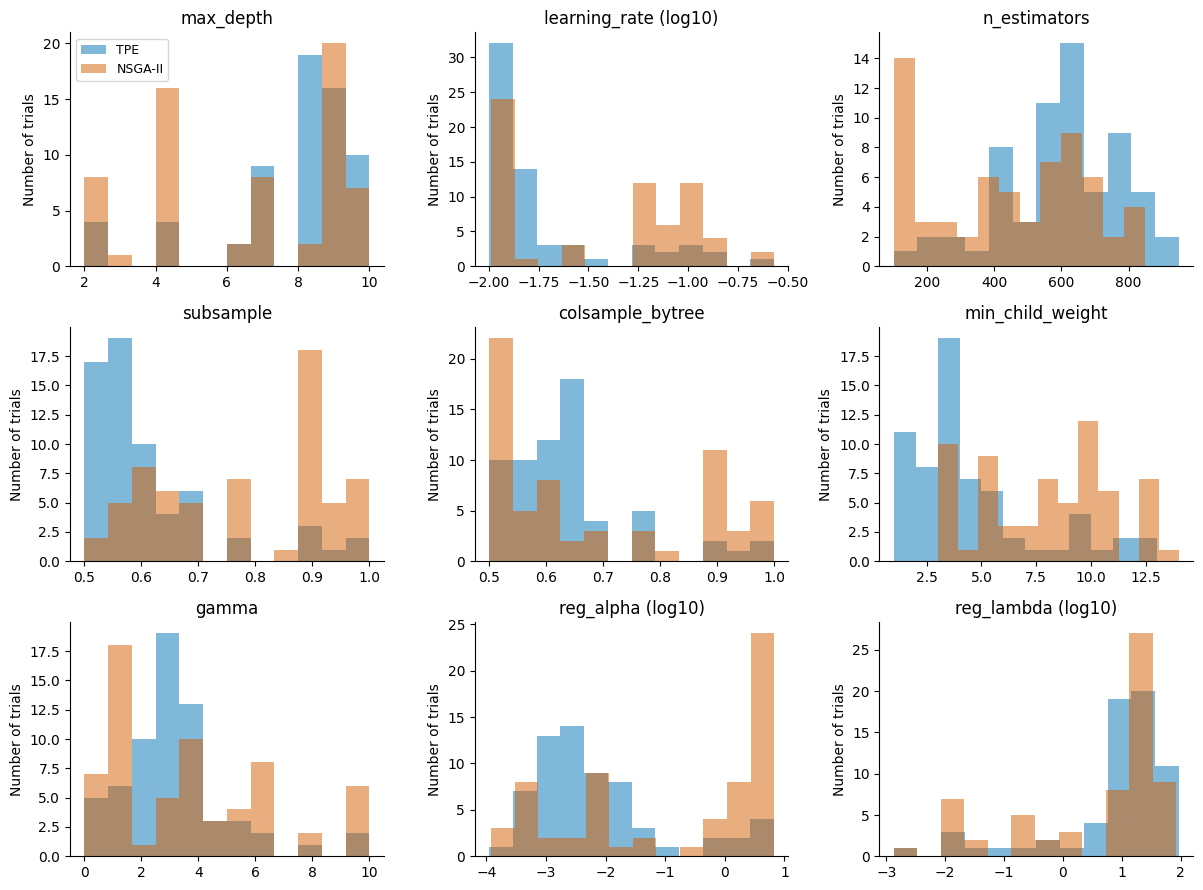

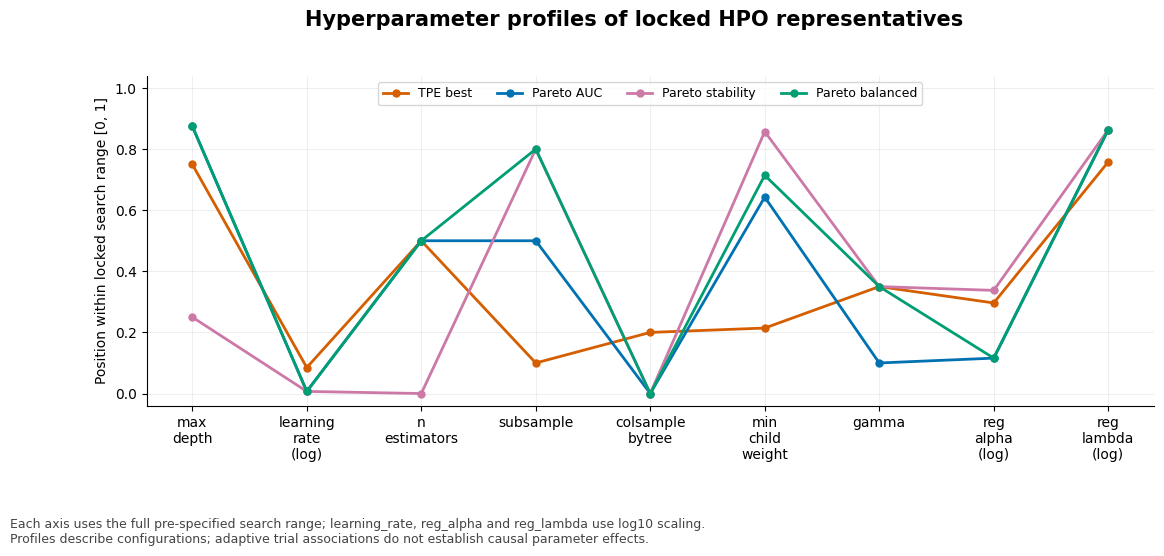

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for ax, name in zip(axes.flat, parameters):
    for sampler, frame, color in [('TPE', single, '#0072B2'), ('NSGA-II', multi, '#D55E00')]:
        values = frame[f'param_{name}']
        if search_config[name].get('log', False):
            values = np.log10(values)
        ax.hist(values, bins=12, alpha=0.5, label=sampler, color=color)
    ax.set_title(name + (' (log10)' if search_config[name].get('log', False) else ''))
    ax.set_ylabel('Number of trials')
axes.flat[0].legend()
fig.tight_layout()
show_figure(fig)
show_figure(viz.plot_hyperparameter_tradeoff(single_best, selected, trials=multi))


## 3. RQ2: TPE tối ưu AUC có ổn định mọi khía cạnh?

So sánh cả Spearman trên toàn bộ 23 biến và Jaccard chỉ trên top-5. Global importance được tính bằng trung bình trị tuyệt đối SHAP **raw log-odds margin**, TreeSHAP `tree_path_dependent`; importance của các cột one-hot được gộp về biến gốc trước đánh giá thứ hạng.


In [6]:
tpe_point = single_best.iloc[0]
default_point = default.iloc[0]
display(pd.DataFrame([{'configuration': 'Default XGBoost', **default_point[['roc_auc_cv', 'shap_stability', 'top_5_jaccard']].to_dict()},
                      {'configuration': f"TPE trial {int(tpe_point['trial'])}", **tpe_point[['roc_auc_cv', 'shap_stability', 'top_5_jaccard']].to_dict()}]))
display(Markdown(f"TPE tăng AUC **{tpe_point['roc_auc_cv'] - default_point['roc_auc_cv']:+.6f}** "
                 f"và Spearman **{tpe_point['shap_stability'] - default_point['shap_stability']:+.6f}**, "
                 f"nhưng Jaccard top-5 thay đổi **{tpe_point['top_5_jaccard'] - default_point['top_5_jaccard']:+.6f}**. "
                 "**RQ2: tối ưu AUC không bảo đảm tập top-5 ổn định.** Hai chỉ số stability mô tả hai thuộc tính khác nhau."))


,configuration,roc_auc_cv,shap_stability,top_5_jaccard
0,Default XGBoost,0.772620,0.816008,0.866667
1,TPE trial 50,0.787436,0.901482,0.733333


TPE tăng AUC **+0.014815** và Spearman **+0.085474**, nhưng Jaccard top-5 thay đổi **-0.133333**. **RQ2: tối ưu AUC không bảo đảm tập top-5 ổn định.** Hai chỉ số stability mô tả hai thuộc tính khác nhau.

## 4. RQ3: kiểm toán front và không gian hai mục tiêu

Với hai mục tiêu đều tối đa hóa, $a$ chi phối $b$ khi $a_1\ge b_1$, $a_2\ge b_2$ và ít nhất một bất đẳng thức nghiêm. Điểm có hai mục tiêu bằng nhau không chi phối nhau. Cell sau tự tính quan hệ chi phối từ bảng trial, rồi so với front đã xuất và bản kiểm toán.

Điểm $(1,1)$ trên **thang mục tiêu gốc** biểu thị AUC và Spearman hoàn hảo, chỉ là mốc lý tưởng. Nó khác điểm lý tưởng của hai mục tiêu được chuẩn hóa theo min–max trong bước chọn đại diện.


,trial,roc_auc_cv,shap_stability,top_5_jaccard
1,44,0.787721,0.933498,0.733333
3,56,0.787270,0.941403,0.595238
5,61,0.786497,0.950198,0.595238
0,22,0.785528,0.950296,0.628571
2,53,0.780534,0.969664,0.766667
4,57,0.775843,0.973594,0.766667


Front tự tính khớp front xuất và Optuna: [22, 44, 53, 56, 57, 61]


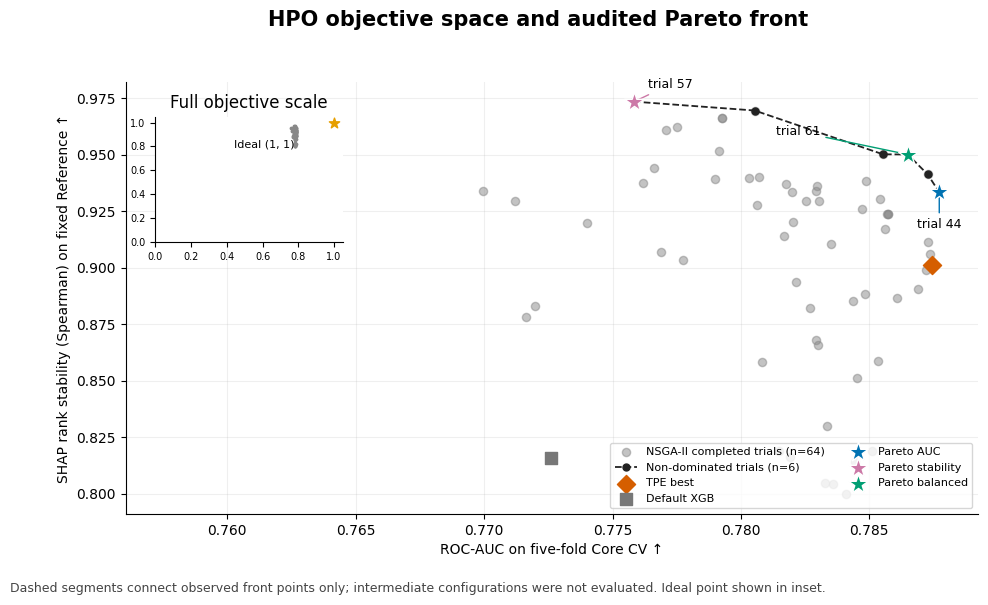

In [7]:
objectives = multi[['roc_auc_cv', 'shap_stability']].to_numpy()
domination_counts = np.array([np.sum(np.all(objectives >= point, axis=1) &
                                     np.any(objectives > point, axis=1)) for point in objectives])
manual_front_ids = set(multi.loc[domination_counts == 0, 'trial'])
assert manual_front_ids == set(pareto['trial'])
assert manual_front_ids == set(audit.loc[audit['pareto_manual'], 'trial'])
assert audit['pareto_manual'].equals(audit['pareto_optuna'])
display(pareto[['trial', 'roc_auc_cv', 'shap_stability', 'top_5_jaccard']].sort_values('roc_auc_cv', ascending=False))
print('Front tự tính khớp front xuất và Optuna:', sorted(manual_front_ids))
show_figure(viz.plot_objective_space_pareto(multi, pareto, selected, single_best, default))


## 5. Minh họa min–max và chọn ba đại diện

Với các **cặp mục tiêu duy nhất trên Pareto front**, đặt

$$\tilde f_j(\theta)=\frac{f_j(\theta)-\min_{\phi\in P} f_j(\phi)}{\max_{\phi\in P} f_j(\phi)-\min_{\phi\in P} f_j(\phi)},\qquad d(\theta)=\sqrt{(1-\tilde f_1)^2+(1-\tilde f_2)^2}.$$

Nếu một chiều không có biến thiên, quy ước giá trị chuẩn hóa là 1. Chọn nghiệm AUC cao nhất; chọn nghiệm stability cao nhất nếu khác nghiệm đầu; chọn Balanced trong **các nghiệm còn lại**, có $d$ nhỏ nhất. Các trường hợp hòa dùng thứ tự AUC, stability rồi trial nhỏ hơn, theo `select_representatives`.

Min–max lấy biên từ front, không lấy toàn bộ trial hoặc Final Test. Quy tắc trọng số bằng nhau này là quyết định thiết kế; Balanced không phải cấu hình ngân hàng tối ưu cho mọi cost-matrix.


,trial,roc_auc_cv,shap_stability,normalized_auc,normalized_stability,ideal_distance
5,61,0.786497,0.950198,0.896970,0.416487,0.592539
0,22,0.785528,0.950296,0.815356,0.418952,0.609681
2,53,0.780534,0.969664,0.394937,0.901978,0.612952
3,56,0.787270,0.941403,0.962015,0.197154,0.803744
1,44,0.787721,0.933498,1.000000,0.000000,1.000000
4,57,0.775843,0.973594,0.000000,1.000000,1.000000


,selection_role,trial,roc_auc_cv,shap_stability,top_5_jaccard,ideal_distance
0,auc,44,0.787721,0.933498,0.733333,1.000000
1,stability,57,0.775843,0.973594,0.766667,1.000000
2,balanced,61,0.786497,0.950198,0.595238,0.592539


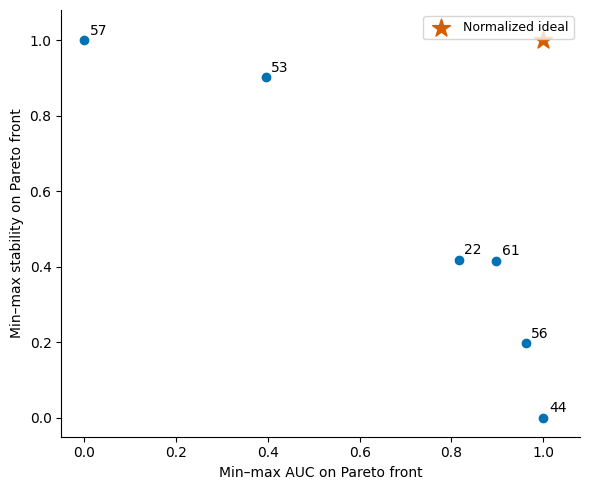

In [8]:
from creditrisk.pareto import select_representatives

unique_front = pareto.sort_values('trial').drop_duplicates(['roc_auc_cv', 'shap_stability']).copy()
for source, destination in [('roc_auc_cv', 'normalized_auc'), ('shap_stability', 'normalized_stability')]:
    low, high = unique_front[source].min(), unique_front[source].max()
    unique_front[destination] = 1.0 if high == low else (unique_front[source] - low) / (high - low)
unique_front['ideal_distance'] = np.hypot(1 - unique_front['normalized_auc'], 1 - unique_front['normalized_stability'])
display(unique_front[['trial', 'roc_auc_cv', 'shap_stability', 'normalized_auc', 'normalized_stability', 'ideal_distance']]
        .sort_values('ideal_distance'))
recomputed = pd.DataFrame(select_representatives(multi.to_dict('records')))
assert recomputed.set_index('role')['trial'].to_dict() == selected.set_index('selection_role')['trial'].to_dict()
for column in ['normalized_auc', 'normalized_stability', 'ideal_distance']:
    assert np.allclose(recomputed.set_index('trial')[column].sort_index(), selected.set_index('trial')[column].sort_index())
display(selected[['selection_role', 'trial', 'roc_auc_cv', 'shap_stability', 'top_5_jaccard', 'ideal_distance']])
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(unique_front['normalized_auc'], unique_front['normalized_stability'], color='#0072B2')
for row in unique_front.itertuples():
    ax.annotate(str(row.trial), (row.normalized_auc, row.normalized_stability), xytext=(4, 4), textcoords='offset points')
ax.scatter([1], [1], marker='*', s=180, color='#D55E00', label='Normalized ideal')
ax.set(xlabel='Min–max AUC on Pareto front', ylabel='Min–max stability on Pareto front', xlim=(-0.05, 1.08), ylim=(-0.05, 1.08))
ax.legend()
fig.tight_layout()
show_figure(fig)


## 6. Cấu hình cụ thể và diễn giải trade-off

Độ sâu cao tăng khả năng mô tả tương tác; số cây và learning rate phối hợp điều tiết độ phức tạp; subsample/colsample thay đổi tín hiệu mỗi cây; `min_child_weight`, `gamma`, L1/L2 điều tiết nhánh và trọng số lá. Đây là cơ chế có thể giải thích các quan sát, không chứng minh quan hệ nhân quả từ 64 trial.

So sánh cụ thể các cấu hình thay vì kết luận một tham số đơn lẻ luôn làm tăng/giảm stability. Đặc biệt các biến thanh toán/hóa đơn tương quan có thể trao đổi thứ hạng, khiến Spearman toàn cục và giao top-5 đi theo hai chiều khác nhau.


In [9]:
configurations = pd.concat([single_best.assign(configuration='TPE best'),
                            selected.assign(configuration=selected['selection_role'].map(lambda role: f'Pareto {role}'))], ignore_index=True)
display(configurations[['configuration', 'trial'] + parameter_columns].set_index('configuration'))
display(comparison[['source', 'selection_role', 'trial', 'roc_auc_cv', 'shap_stability',
                    'top_5_jaccard', 'delta_auc_vs_tpe_best', 'delta_stability_vs_tpe_best']])
balanced = selected.set_index('selection_role').loc['balanced']
display(Markdown(f"**RQ3:** Balanced trial **{int(balanced['trial'])}** đạt AUC **{balanced['roc_auc_cv']:.6f}** "
                 f"(Δ so với TPE {balanced['roc_auc_cv'] - tpe_point['roc_auc_cv']:+.6f}), "
                 f"Spearman **{balanced['shap_stability']:.6f}** "
                 f"(Δ {balanced['shap_stability'] - tpe_point['shap_stability']:+.6f}), "
                 f"nhưng Jaccard **{balanced['top_5_jaccard']:.6f}**. "
                 "NSGA-II tìm được trade-off tốt hơn về hai mục tiêu đã định nghĩa; chưa suy rộng thành ưu thế trên mọi dạng stability."))


,trial,param_max_depth,param_learning_rate,param_n_estimators,param_subsample,param_colsample_bytree,param_min_child_weight,param_gamma,param_reg_alpha,param_reg_lambda
configuration,,,,,,,,,,
TPE best,50,8,0.013356,550,0.550000,0.600000,4,3.500000,0.003035,6.150117
Pareto auc,44,9,0.010239,550,0.750000,0.500000,10,1.000000,0.000380,20.678409
Pareto stability,57,4,0.010239,100,0.900000,0.500000,13,3.500000,0.004876,20.678409
Pareto balanced,61,9,0.010239,550,0.900000,0.500000,11,3.500000,0.000380,20.678409


,source,selection_role,trial,roc_auc_cv,shap_stability,top_5_jaccard,delta_auc_vs_tpe_best,delta_stability_vs_tpe_best
0,xgboost_default,default,NaN,0.772620,0.816008,0.866667,-0.014815,-0.085474
1,xgb_auc_tpe,auc_best_tpe,50.000000,0.787436,0.901482,0.733333,0.000000,0.000000
2,xgb_auc_shap_nsgaii,auc,44.000000,0.787721,0.933498,0.733333,0.000286,0.032016
3,xgb_auc_shap_nsgaii,stability,57.000000,0.775843,0.973594,0.766667,-0.011593,0.072112
4,xgb_auc_shap_nsgaii,balanced,61.000000,0.786497,0.950198,0.595238,-0.000938,0.048715


**RQ3:** Balanced trial **61** đạt AUC **0.786497** (Δ so với TPE -0.000938), Spearman **0.950198** (Δ +0.048715), nhưng Jaccard **0.595238**. NSGA-II tìm được trade-off tốt hơn về hai mục tiêu đã định nghĩa; chưa suy rộng thành ưu thế trên mọi dạng stability.

### Tự kiểm tra và bước tiếp theo

1. Vì sao phải xem chất lượng hồi quy phụ trước khi diễn giải permutation importance?
2. Vì sao đổi biên chuẩn hóa có thể đổi nghiệm Balanced?
3. Một nghiệm Spearman cao hơn nhưng Jaccard thấp hơn có thể phù hợp mục tiêu nghiên cứu không?

**RQ1:** các tham số thể hiện liên hệ và tương tác trong vùng đã khảo sát; importance thăm dò cần đọc cùng chất lượng mô hình phụ. **RQ2:** TPE không bảo đảm ổn định top-5. **RQ3:** NSGA-II tạo sáu nghiệm Pareto và ba lựa chọn cụ thể trên Development.

Tiếp tục [06. Độ nhạy và đánh giá cuối](06_sensitivity_and_final_evaluation.ipynb); giữ nguyên ba trial và TPE best, không chọn lại sau khi xem Final Test.
